# CWRU 실제 데이터 기반 회전설비 진동 분석 노트북

이 노트북은 **Case Western Reserve University (CWRU) Bearing Data Center**의 실제 베어링 진동 데이터를 사용해:

1. `.mat` 파일 구조 이해  
2. 정상 vs 고장 진동 신호 비교  
3. FFT 시각화  
4. RMS / Kurtosis / Crest Factor 등 특성 추출  
5. 윈도우 기반 feature table 생성  
6. 간단한 고장 분류(RandomForest)  

까지 수행하는 예제

---

## 사전 준비

1. CWRU Bearing Data Center에서 `.mat` 파일을 다운로드
2. 다운로드한 파일을 아래 폴더에 저장

```text
data/raw/cwru/
```


- 정상 파일 2개
- 고장 파일 2개

## CWRU 데이터셋 메모

- CWRU Bearing Data Center에서 제공하는 실제 베어링 진동 데이터
- 공식 설명에 따르면 데이터는 정상 베어링과 단일 결함(single-point fault) 베어링에 대해 수집되었고, drive end/fan end/base 측정값과 RPM이 포함될 수 있으며, Matlab `.mat` 형식으로 제공됨.
- 또한 drive-end 실험은 12,000 samples/sec와 48,000 samples/sec 버전이 있고, fan-end 데이터는 12,000 samples/sec로 제공됨. 테스트 장비는 2 hp motor, torque transducer/encoder, dynamometer로 구성되며, 결함은 EDM 방식으로 주입됨

## 권장 폴더 구조

```text
industrial-predictive-maintenance-poc/
├─ data/
│  └─ raw/
│     └─ cwru/
│        ├─ 97.mat
│        ├─ 98.mat
│        ├─ 105.mat
│        └─ 106.mat
└─ notebooks/
   └─ cwru_real_data_analysis.ipynb
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score

## 1. 기본 설정

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CWRU_DIR = Path("../data/raw/cwru")
SAMPLING_RATE = 12000   # 기본 예시: 12k 데이터 가정
WINDOW_SIZE = 2048
STEP_SIZE = 1024

print("CWRU_DIR:", CWRU_DIR.resolve())
print("Exists:", CWRU_DIR.exists())

CWRU_DIR: /Users/joiy/Dropbox/Biz/wishket/202604_Predictive_Maintenance/predictive_maintenance_analysis/src/cwru_bearing_data_analysis/data/raw/cwru
Exists: True


## 2. 파일 목록 확인

In [4]:
mat_files = sorted(CWRU_DIR.glob("*.mat"))
print("number of .mat files:", len(mat_files))
mat_files[:20]

number of .mat files: 4


[PosixPath('../data/raw/cwru/105.mat'),
 PosixPath('../data/raw/cwru/106.mat'),
 PosixPath('../data/raw/cwru/97.mat'),
 PosixPath('../data/raw/cwru/98.mat')]

파일이 안 보이면:
- 경로가 맞는지
- `.mat` 파일이 실제로 들어있는지  
먼저 확인 필요.

## 3. `.mat` 파일 구조 살펴보기

In [5]:
if len(mat_files) == 0:
    print("먼저 data/raw/cwru/ 폴더에 .mat 파일을 넣어주세요.")
else:
    sample_file = mat_files[0]
    mat = loadmat(str(sample_file))
    print("sample_file:", sample_file.name)
    print("keys:")
    print(mat.keys())

sample_file: 105.mat
keys:
dict_keys(['__header__', '__version__', '__globals__', 'X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM'])


CWRU 공식 데이터는 파일 안에 보통 다음과 비슷한 이름의 변수를 포함

- `*_DE_time` : Drive End 진동 시계열
- `*_FE_time` : Fan End 진동 시계열
- `*_BA_time` : Base 진동 시계열
- `X###RPM` : 회전수

## 4. 유틸 함수

In [6]:
def find_signal_keys(mat_dict):
    keys = []
    for k in mat_dict.keys():
        if k.startswith("__"):
            continue
        if "DE_time" in k or "FE_time" in k or "BA_time" in k:
            keys.append(k)
    return keys

def find_rpm_keys(mat_dict):
    keys = []
    for k in mat_dict.keys():
        if k.startswith("__"):
            continue
        if "RPM" in k.upper():
            keys.append(k)
    return keys

def extract_1d_signal_from_mat(mat_dict, preferred_key="DE_time"):
    signal_keys = find_signal_keys(mat_dict)

    selected_key = None
    for k in signal_keys:
        if preferred_key in k:
            selected_key = k
            break

    if selected_key is None and signal_keys:
        selected_key = signal_keys[0]

    if selected_key is None:
        raise ValueError("No valid signal key found in mat file.")

    signal = np.ravel(mat_dict[selected_key]).astype(float)
    return selected_key, signal

def extract_rpm_from_mat(mat_dict):
    rpm_keys = find_rpm_keys(mat_dict)
    if not rpm_keys:
        return None, None
    key = rpm_keys[0]
    val = np.ravel(mat_dict[key])
    if len(val) == 0:
        return key, None
    return key, float(val[0])

def load_signal(file_path, preferred_key="DE_time"):
    mat = loadmat(str(file_path))
    signal_key, signal = extract_1d_signal_from_mat(mat, preferred_key=preferred_key)
    rpm_key, rpm = extract_rpm_from_mat(mat)
    return {
        "file": Path(file_path).name,
        "signal_key": signal_key,
        "rpm_key": rpm_key,
        "rpm": rpm,
        "signal": signal,
    }

## 5. 샘플 파일 로드

In [7]:
if len(mat_files) > 0:
    sample_data = load_signal(mat_files[0], preferred_key="DE_time")
    print("file:", sample_data["file"])
    print("signal_key:", sample_data["signal_key"])
    print("rpm_key:", sample_data["rpm_key"])
    print("rpm:", sample_data["rpm"])
    print("signal length:", len(sample_data["signal"]))
    print("first 10 values:", sample_data["signal"][:10])

file: 105.mat
signal_key: X105_DE_time
rpm_key: X105RPM
rpm: 1797.0
signal length: 121265
first 10 values: [-0.08300435 -0.19573433  0.23341928  0.10395848 -0.18111517  0.05555281
  0.17380559 -0.04694375 -0.1119178   0.05961369]


## 6. 시간영역 파형 시각화

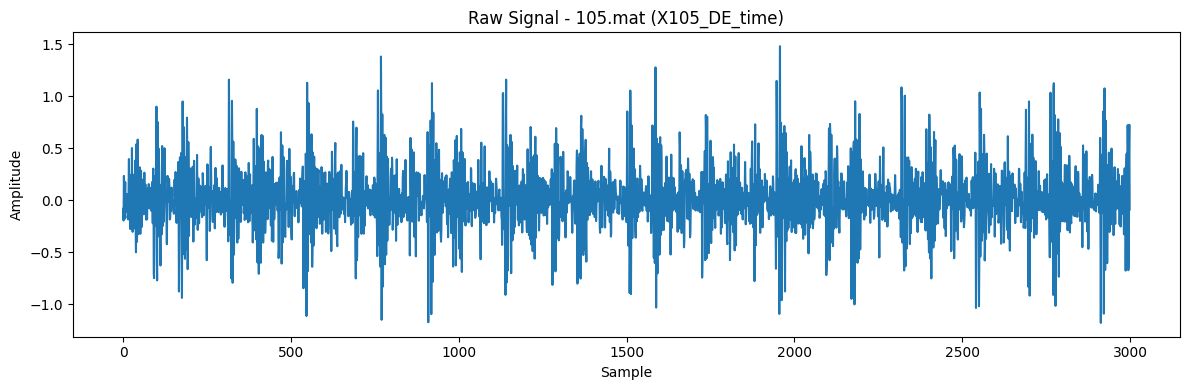

In [8]:
def plot_signal(signal, title="Signal", n_samples=3000):
    plt.figure(figsize=(12, 4))
    plt.plot(signal[:n_samples])
    plt.title(title)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

if len(mat_files) > 0:
    plot_signal(sample_data["signal"], title=f"Raw Signal - {sample_data['file']} ({sample_data['signal_key']})")

## 7. FFT 시각화

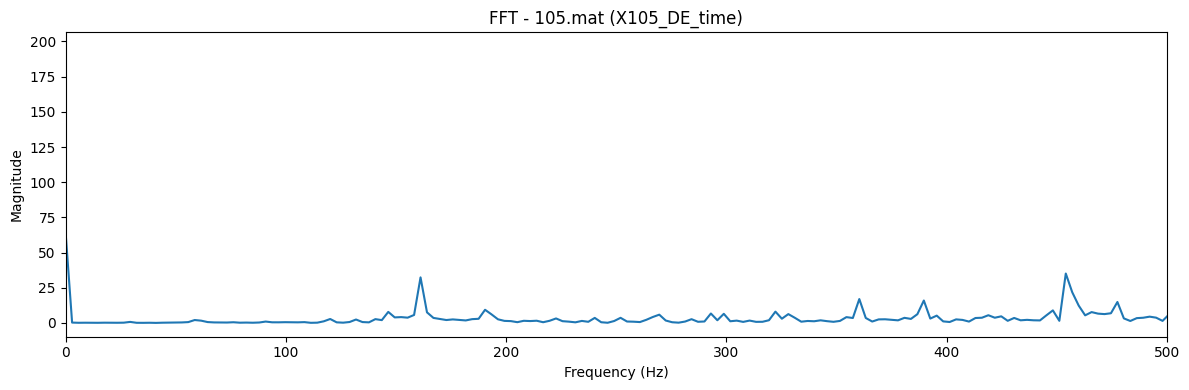

In [9]:
def compute_fft(signal, sampling_rate=SAMPLING_RATE):
    n = len(signal)
    xf = rfftfreq(n, 1 / sampling_rate)
    yf = np.abs(rfft(signal))
    return xf, yf

def plot_fft(signal, sampling_rate=SAMPLING_RATE, title="FFT", max_freq=500):
    xf, yf = compute_fft(signal, sampling_rate)
    plt.figure(figsize=(12, 4))
    plt.plot(xf, yf)
    plt.xlim(0, max_freq)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.tight_layout()
    plt.show()

if len(mat_files) > 0:
    plot_fft(sample_data["signal"][:4096], title=f"FFT - {sample_data['file']} ({sample_data['signal_key']})")

## 8. 정상 / 고장 파일 지정

In [ ]:

healthy_files = [
    CWRU_DIR / "97.mat",
    CWRU_DIR / "98.mat",
]

faulty_files = [
    CWRU_DIR / "105.mat",
    CWRU_DIR / "106.mat",
]

print("healthy_files:", healthy_files)
print("faulty_files:", faulty_files)

healthy_files: [PosixPath('../data/raw/cwru/97.mat'), PosixPath('../data/raw/cwru/98.mat')]
faulty_files: [PosixPath('../data/raw/cwru/105.mat'), PosixPath('../data/raw/cwru/106.mat')]


## 9. 정상 / 고장 신호 비교

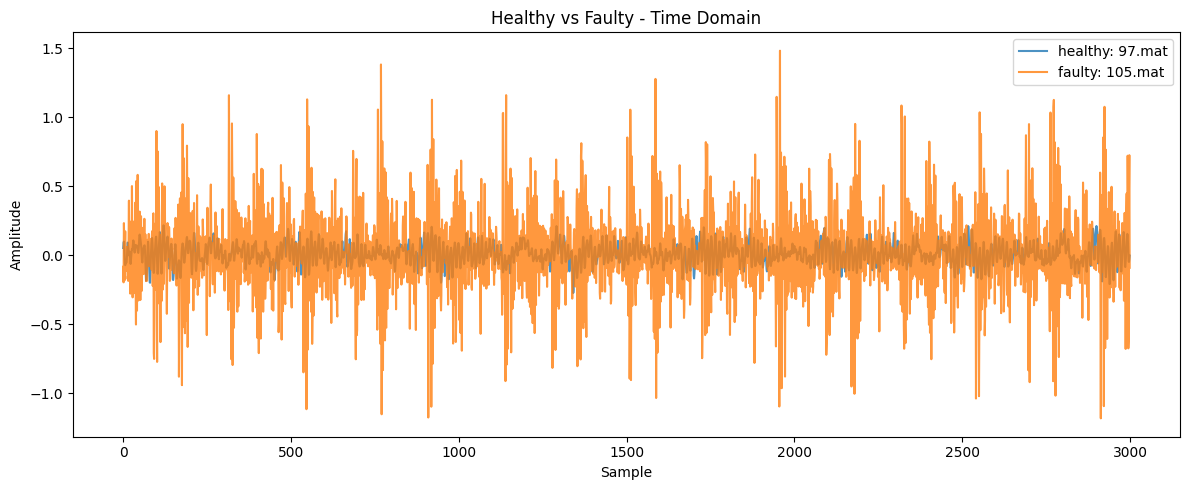

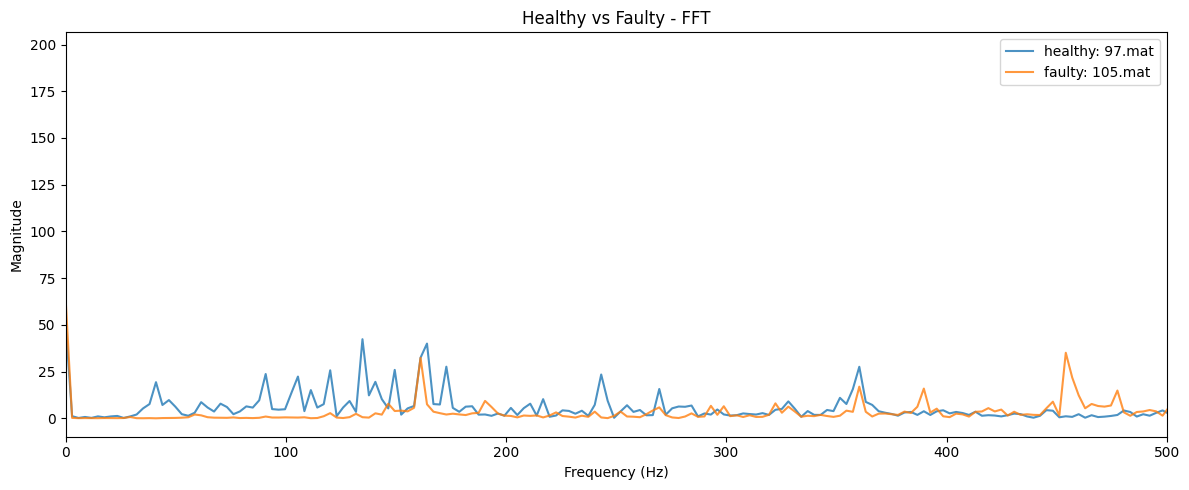

In [11]:
def compare_two_signals(file_a, file_b, preferred_key="DE_time", n_samples=3000, sampling_rate=SAMPLING_RATE):
    a = load_signal(file_a, preferred_key)
    b = load_signal(file_b, preferred_key)

    plt.figure(figsize=(12, 5))
    plt.plot(a["signal"][:n_samples], label=f"healthy: {a['file']}", alpha=0.8)
    plt.plot(b["signal"][:n_samples], label=f"faulty: {b['file']}", alpha=0.8)
    plt.title("Healthy vs Faulty - Time Domain")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    xf_a, yf_a = compute_fft(a["signal"][:4096], sampling_rate)
    xf_b, yf_b = compute_fft(b["signal"][:4096], sampling_rate)

    plt.figure(figsize=(12, 5))
    plt.plot(xf_a, yf_a, label=f"healthy: {a['file']}", alpha=0.8)
    plt.plot(xf_b, yf_b, label=f"faulty: {b['file']}", alpha=0.8)
    plt.xlim(0, 500)
    plt.title("Healthy vs Faulty - FFT")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

if len(healthy_files) > 0 and len(faulty_files) > 0:
    compare_two_signals(healthy_files[0], faulty_files[0])
else:
    print("healthy_files와 faulty_files를 먼저 채워주세요.")

## 10. 특성 추출 함수

In [12]:
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def crest_factor(x):
    x_rms = rms(x)
    if x_rms == 0:
        return 0.0
    return np.max(np.abs(x)) / x_rms

def band_energy(xf, yf, low, high):
    mask = (xf >= low) & (xf < high)
    return float(np.sum(yf[mask] ** 2))

def extract_features(signal, sampling_rate=SAMPLING_RATE):
    xf, yf = compute_fft(signal, sampling_rate)
    dom_idx = np.argmax(yf[1:]) + 1 if len(yf) > 1 else 0
    dom_freq = xf[dom_idx] if len(xf) > dom_idx else 0.0

    low_band = band_energy(xf, yf, 0, 60)
    mid_band = band_energy(xf, yf, 60, 180)
    high_band = band_energy(xf, yf, 180, 500)
    total_band = low_band + mid_band + high_band + 1e-12

    return {
        "mean": float(np.mean(signal)),
        "std": float(np.std(signal)),
        "rms": float(rms(signal)),
        "max_abs": float(np.max(np.abs(signal))),
        "peak_to_peak": float(np.ptp(signal)),
        "kurtosis": float(kurtosis(signal)),
        "skewness": float(skew(signal)),
        "crest_factor": float(crest_factor(signal)),
        "dominant_freq": float(dom_freq),
        "spectral_energy": float(np.sum(yf ** 2)),
        "low_band_ratio": float(low_band / total_band),
        "mid_band_ratio": float(mid_band / total_band),
        "high_band_ratio": float(high_band / total_band),
    }

## 11. 윈도우 분할 함수

In [13]:
def window_signal(signal, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])
    return windows

## 12. 파일 여러 개에서 feature table 만들기

In [14]:
def build_dataset_from_files(file_list, label, sampling_rate=SAMPLING_RATE, window_size=WINDOW_SIZE, step_size=STEP_SIZE, preferred_key="DE_time"):
    rows = []

    for file_path in file_list:
        try:
            loaded = load_signal(file_path, preferred_key=preferred_key)
            windows = window_signal(loaded["signal"], window_size=window_size, step_size=step_size)

            for i, w in enumerate(windows):
                feat = extract_features(w, sampling_rate=sampling_rate)
                feat["label"] = label
                feat["source_file"] = loaded["file"]
                feat["signal_key"] = loaded["signal_key"]
                feat["window_id"] = i
                feat["rpm"] = loaded["rpm"]
                rows.append(feat)
        except Exception as e:
            print(f"Failed to process {file_path}: {e}")

    return pd.DataFrame(rows)

## 13. feature table 생성

In [15]:
if len(healthy_files) > 0 and len(faulty_files) > 0:
    healthy_df = build_dataset_from_files(healthy_files, label=0)
    faulty_df = build_dataset_from_files(faulty_files, label=1)

    feature_df = pd.concat([healthy_df, faulty_df], axis=0, ignore_index=True)
    print("feature_df shape:", feature_df.shape)
    display(feature_df.head())
else:
    feature_df = pd.DataFrame()
    print("healthy_files와 faulty_files를 먼저 채워주세요.")

feature_df shape: (943, 18)


,mean,std,rms,max_abs,peak_to_peak,kurtosis,skewness,crest_factor,dominant_freq,spectral_energy,low_band_ratio,mid_band_ratio,high_band_ratio,label,source_file,signal_key,window_id,rpm
0,0.012005,0.072266,0.073256,0.272869,0.490663,-0.045824,-0.137322,3.724845,1037.109375,11556.623524,0.220321,0.560312,0.219367,0,97.mat,X097_DE_time,0,1796.0
1,0.013116,0.073344,0.074507,0.272869,0.485239,-0.116338,-0.010099,3.662321,1037.109375,12002.722510,0.234712,0.576691,0.188597,0,97.mat,X097_DE_time,1,1796.0
2,0.012790,0.077993,0.079035,0.226765,0.449775,-0.184580,-0.062348,2.869171,1037.109375,13443.007363,0.185409,0.614645,0.199946,0,97.mat,X097_DE_time,2,1796.0
3,0.012148,0.076964,0.077916,0.226765,0.449775,-0.150657,-0.103819,2.910361,1037.109375,13041.230151,0.206224,0.579542,0.214234,0,97.mat,X097_DE_time,3,1796.0
4,0.011959,0.073370,0.074338,0.219255,0.421403,-0.221760,0.025960,2.949440,1037.109375,11888.996122,0.254522,0.548750,0.196728,0,97.mat,X097_DE_time,4,1796.0


## 14. 클래스 분포 확인

In [16]:
if not feature_df.empty:
    print(feature_df["label"].value_counts())

label
0    708
1    235
Name: count, dtype: int64


## 15. 주요 특성 분포 확인

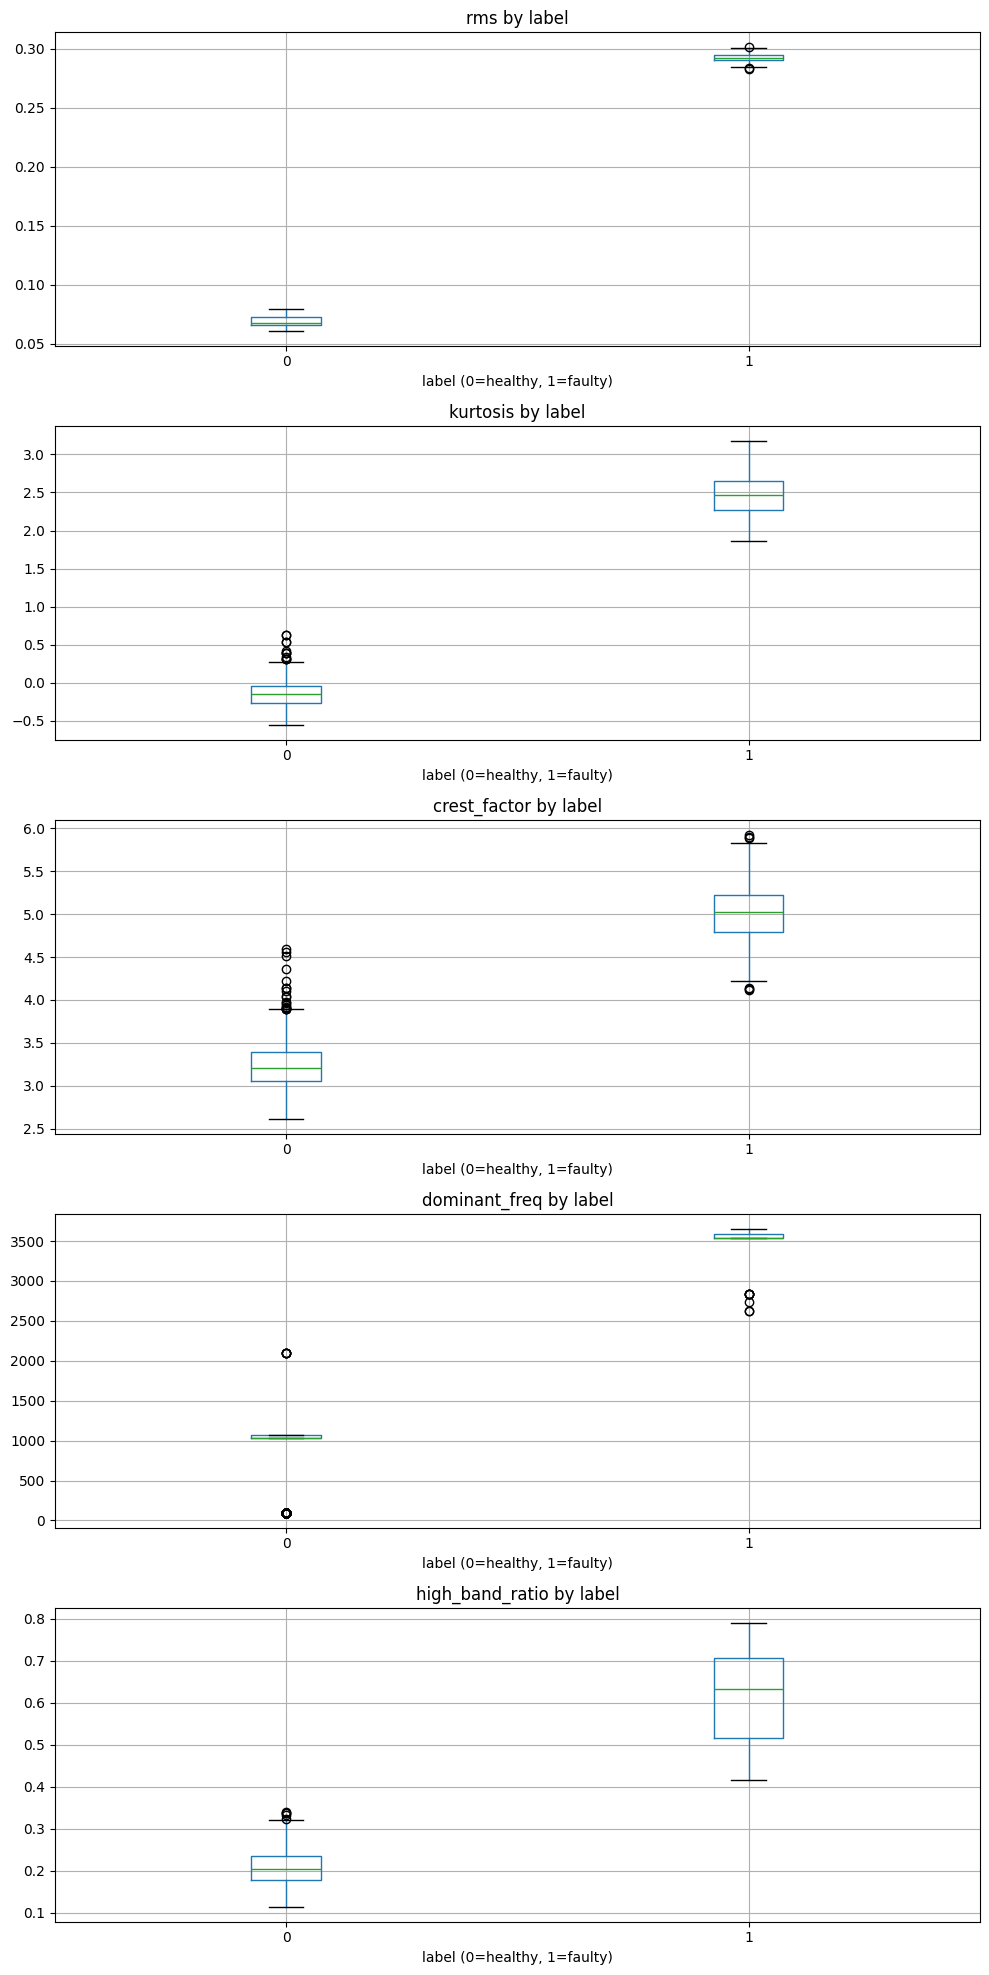

In [17]:
if not feature_df.empty:
    plot_cols = ["rms", "kurtosis", "crest_factor", "dominant_freq", "high_band_ratio"]
    plot_cols = [c for c in plot_cols if c in feature_df.columns]

    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        feature_df.boxplot(column=col, by="label", ax=ax)
        ax.set_title(f"{col} by label")
        ax.set_xlabel("label (0=healthy, 1=faulty)")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 16. 간단한 baseline 분류

처음 포트폴리오 단계에서는 다음 정도면 충분함.

- Logistic Regression
- RandomForest
- PR-AUC
- confusion matrix

In [18]:
if not feature_df.empty:
    feature_cols = [
        c for c in feature_df.columns
        if c not in ["label", "source_file", "signal_key", "window_id"]
    ]

    X = feature_df[feature_cols].copy()
    y = feature_df["label"].copy()

    # rpm이 없는 경우 NaN이 생길 수 있으므로 간단히 중앙값 대체
    X = X.fillna(X.median(numeric_only=True))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    lr_prob = lr.predict_proba(X_test)[:, 1]

    print("=== Logistic Regression ===")
    print(classification_report(y_test, lr_pred, zero_division=0))
    print("PR-AUC:", average_precision_score(y_test, lr_prob))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00        47

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189

PR-AUC: 1.0


In [19]:
if not feature_df.empty:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    print("=== RandomForest ===")
    print(classification_report(y_test, rf_pred, zero_division=0))
    print("PR-AUC:", average_precision_score(y_test, rf_prob))

=== RandomForest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00        47

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189

PR-AUC: 1.0


## 17. Confusion Matrix

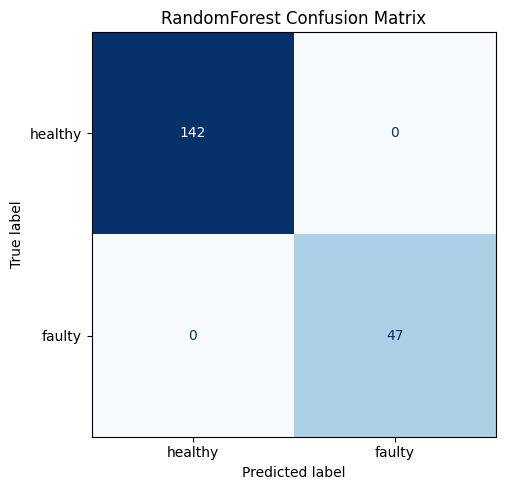

In [20]:
if not feature_df.empty:
    cm = confusion_matrix(y_test, rf_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["healthy", "faulty"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("RandomForest Confusion Matrix")
    plt.tight_layout()
    plt.show()

## 18. Feature Importance

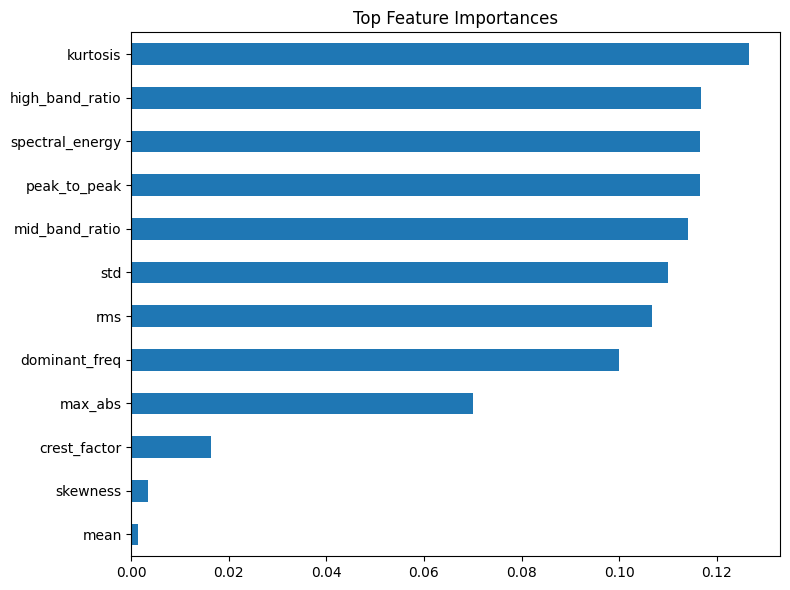

kurtosis           0.126667
high_band_ratio    0.116735
spectral_energy    0.116679
peak_to_peak       0.116667
mid_band_ratio     0.114177
std                0.110024
rms                0.106667
dominant_freq      0.100046
max_abs            0.070058
crest_factor       0.016410
skewness           0.003347
mean               0.001281
dtype: float64

In [21]:
if not feature_df.empty:
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(12).sort_values().plot(kind="barh")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

    display(importances.head(12))

## 19. 해석 포인트

- **RMS**: 전체 진동 레벨 상승 여부
- **Kurtosis / Crest Factor**: 충격성 결함 가능성
- **Dominant Frequency / Band Ratio**: 특정 주파수 대역의 이상 여부
- **RandomForest Feature Importance**: 어떤 특성이 healthy/faulty 분리에 크게 기여했는지

## 20. 다음 확장 아이디어

1. **healthy vs faulty** 이진 분류에서 시작  
2. 이후 **inner race / outer race / ball fault** 다중분류로 확장  
3. 12k vs 48k 데이터 비교  
4. DE / FE 센서 비교  
5. threshold tuning 추가  
6. SHAP 기반 설명 추가  
7. 실제 플랜트 데이터 구조에 맞춘 loader로 일반화